# Predictive maintenance using Machine Learning

**Predictive maintenance aims to predict equipment failures before they occur, reducing downtime and maintenance costs**

## 1. Import Libraries

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

## 2. Load dataset

In [97]:
data = pd.read_csv("predictive_maintenance.csv")
print(data.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  


## 3. Dataset overview

In [98]:
print(data.columns)
print("Shape of data:", data.shape)
print(data.info())
print(data["Failure Type"].unique())
print(data["Target"].unique())
print(data.describe())

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')
Shape of data: (10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: 

## 4. Exploratory Data Analysis

In [99]:
# Inspecting null values
print(f"Count of null data:\n{data.isna().sum()}\n")

#Inspecting number of duplicates
print("Duplicated data:", data.duplicated().sum())

Count of null data:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

Duplicated data: 0


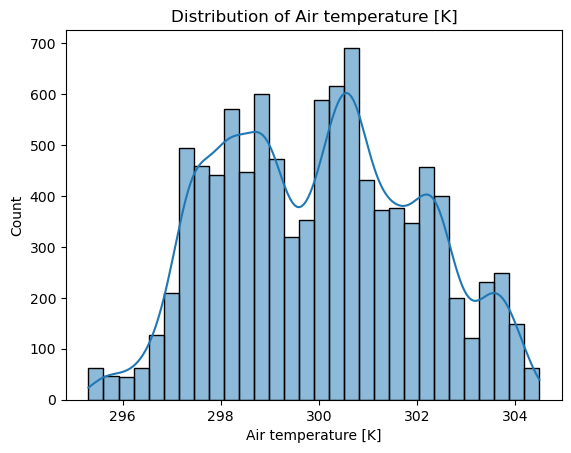

In [100]:
sb.histplot(data['Air temperature [K]'], bins = 30, kde = True, edgecolor = 'black')
plt.title("Distribution of Air temperature [K]")
plt.xlabel("Air temperature [K]")
plt.show()

The air temperature follows an approximately normal distribution with no significant skewness. Most observations are concentrated around the mean, suggesting consistent environmental conditions during data collection.

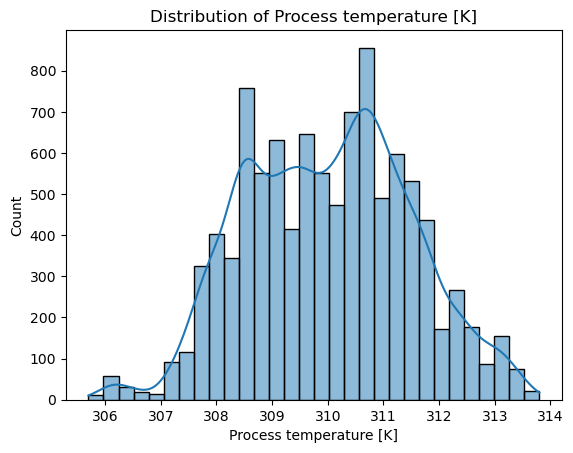

In [101]:
sb.histplot(data['Process temperature [K]'], bins = 30, kde = True, edgecolor = 'black')
plt.title("Distribution of Process temperature [K]")
plt.xlabel("Process temperature [K]")
plt.show()

Similar to air temperature, the process temperature appears approximately normally distributed. No unusual peaks or irregular patterns are observed.

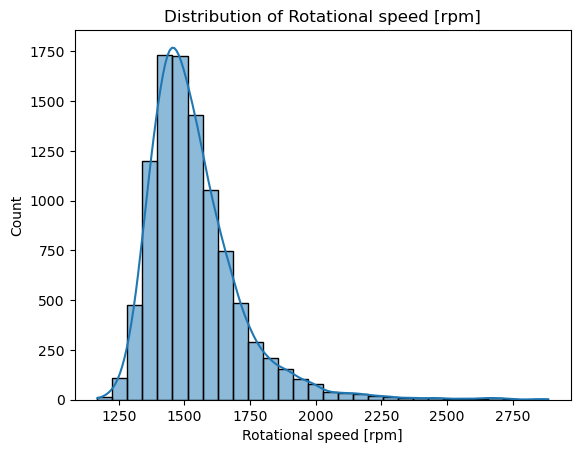

In [102]:
sb.histplot(data['Rotational speed [rpm]'], bins = 30, kde = True, edgecolor = 'black')
plt.title("Distribution of Rotational speed [rpm]")
plt.xlabel("Rotational speed [rpm]")
plt.show()

The rotational speed distribution is positively skewed. Most observations are clustered around moderate rotational speeds, while a relatively small number of observations exhibit substantially higher values. Further analysis using boxplots and summary statistics will help determine whether these observations represent true operating conditions or potential outliers.

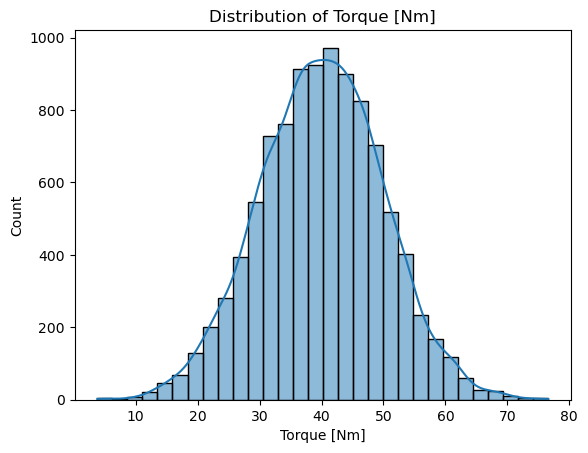

In [103]:
sb.histplot(data['Torque [Nm]'], bins = 30, kde = True, edgecolor = 'black')
plt.title("Distribution of Torque [Nm]")
plt.xlabel("Torque [Nm]")
plt.show()

Similar to air and process temperature, the torque appears approximately normally distributed. No unusual peaks or irregular patterns are observed.

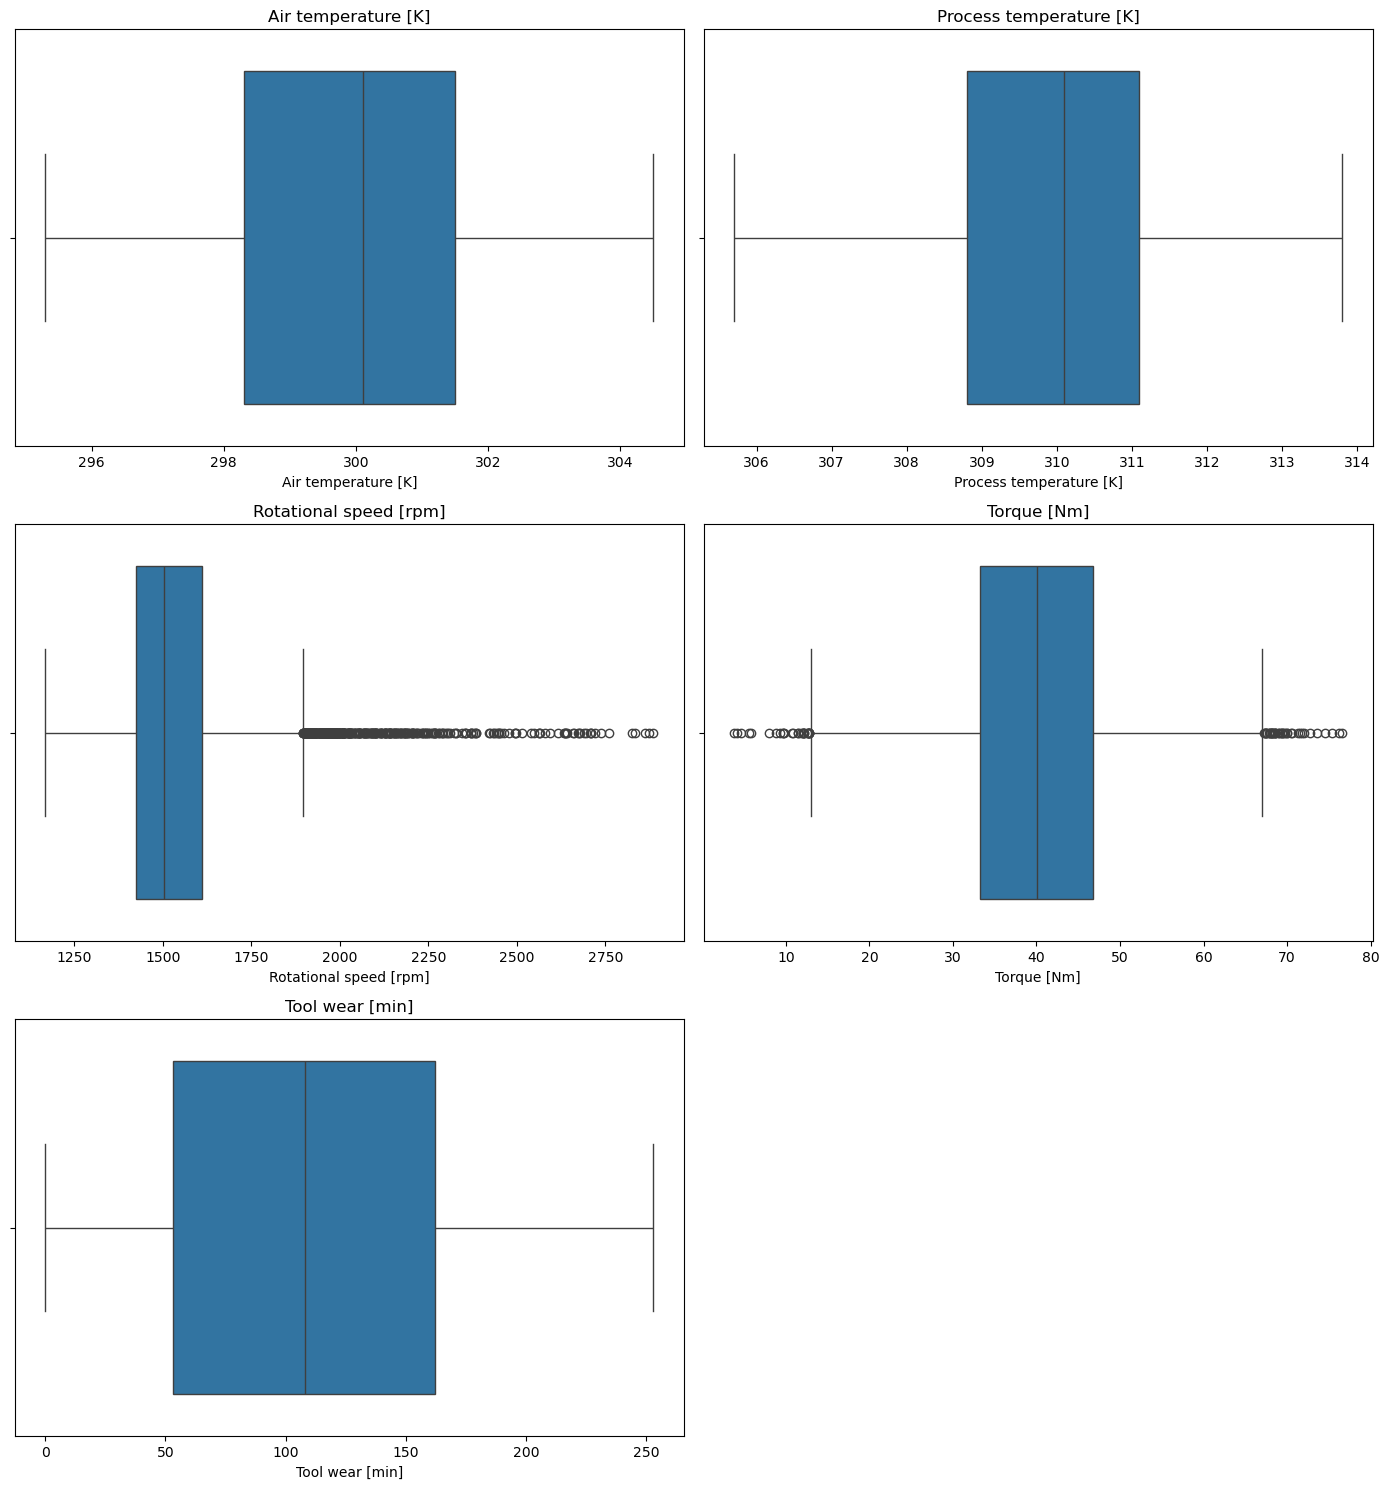

In [104]:
numerical_columns = data.select_dtypes(include="number").columns
numerical_columns = numerical_columns.drop(['UDI', 'Target'])

n_cols = 2
n_rows = int(np.ceil(len(numerical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.array(axes).flatten()

for i, column in enumerate(numerical_columns):
    sb.boxplot(
        x=data[column],
        ax=axes[i]
    )

    axes[i].set_title(column)

for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

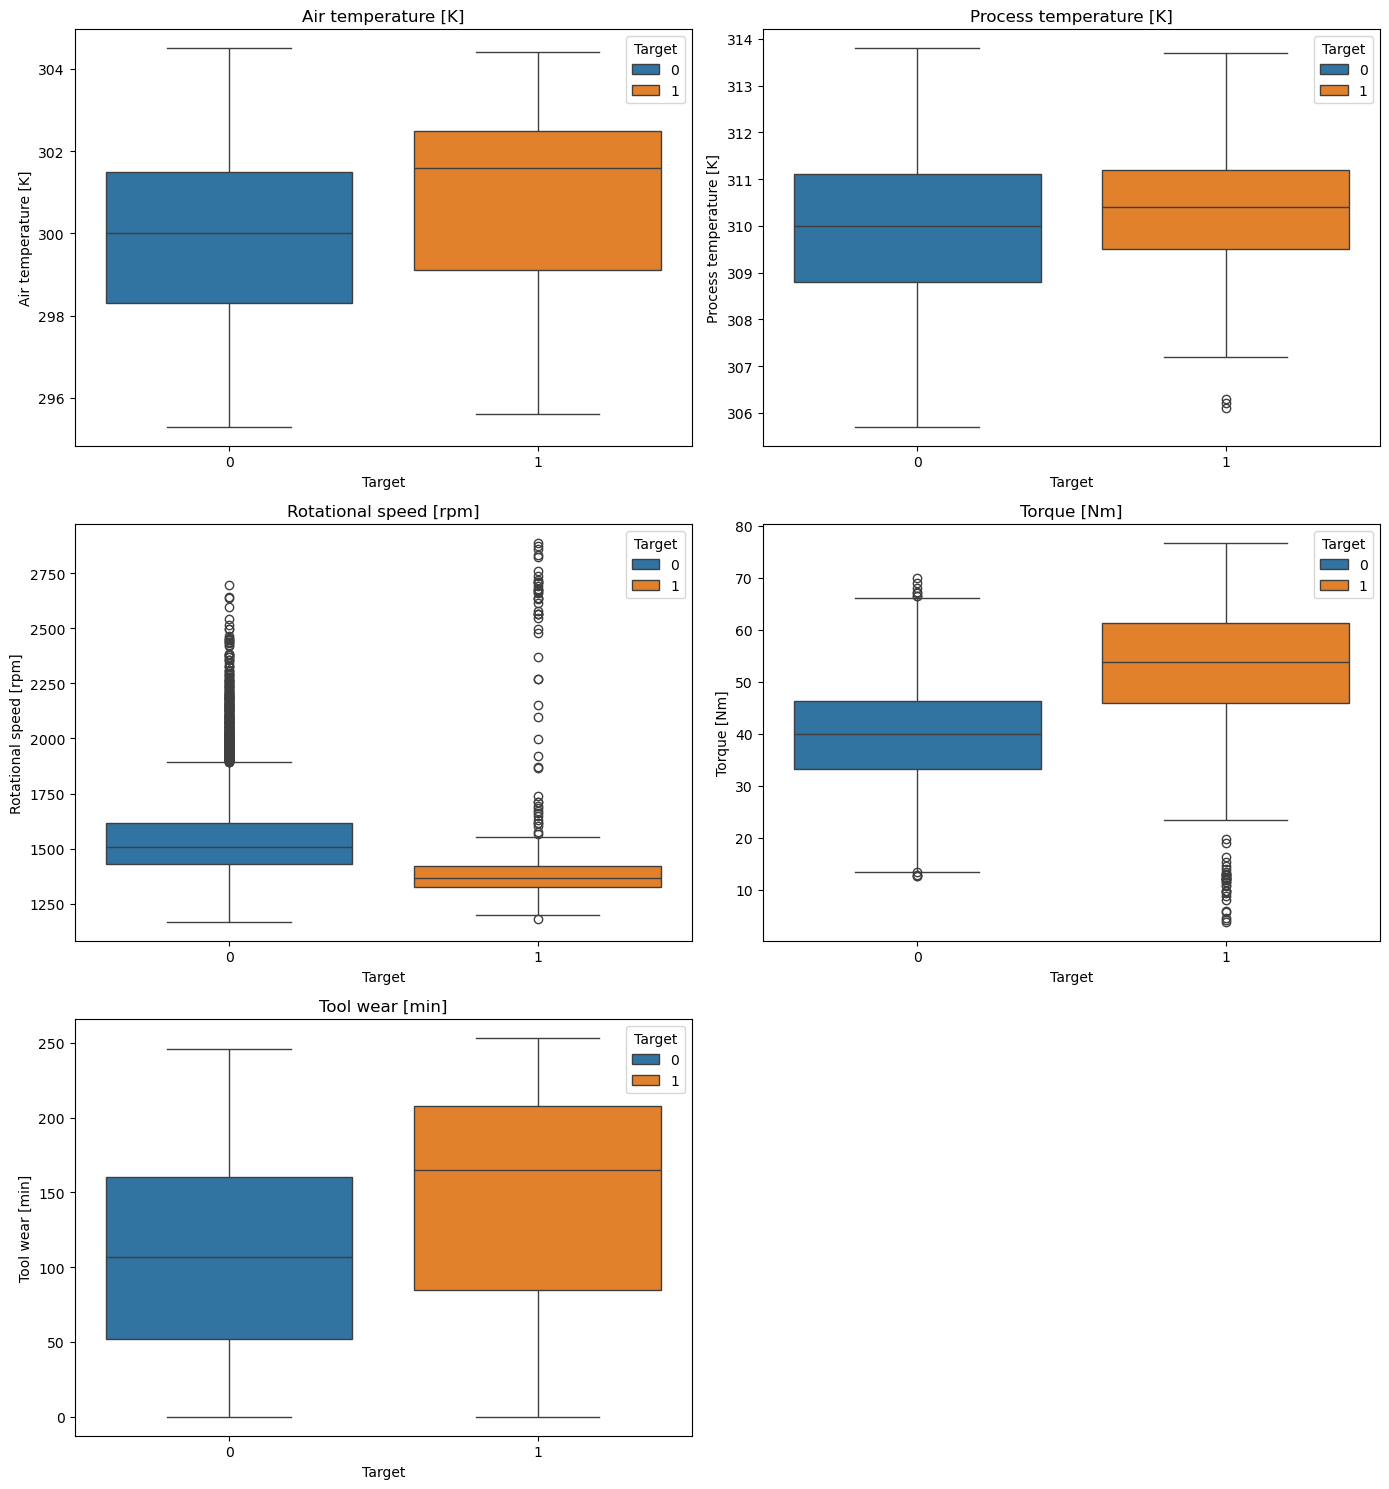

In [112]:
numerical_columns = data.select_dtypes(include="number").columns
numerical_columns = numerical_columns.drop(['UDI', 'Target'])

n_cols = 2
n_rows = int(np.ceil(len(numerical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.array(axes).flatten()

for i, column in enumerate(numerical_columns):
    sb.boxplot(
        x=data['Target'],
        y=data[column],
        hue=data['Target'],
        ax=axes[i]
    )

    axes[i].set_title(column)

for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

**Outliers analysis**

In [113]:
Q1 = data["Rotational speed [rpm]"].quantile(0.25)
Q3 = data["Rotational speed [rpm]"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [114]:
outliers = data[
    (data["Rotational speed [rpm]"] < lower) |
    (data["Rotational speed [rpm]"] > upper)
]

In [115]:
print("Number of outliers:", outliers.shape[0])

Number of outliers: 418


<Axes: xlabel='Target', ylabel='Rotational speed [rpm]'>

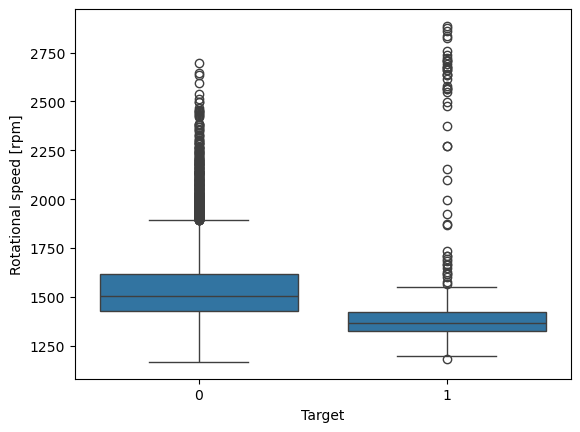

In [116]:
sb.boxplot(
    data=data,
    x="Target",
    y="Rotational speed [rpm]"
)

In [117]:
# Number of categories at outliers
outliers["Target"].value_counts()

Target
0    383
1     35
Name: count, dtype: int64

**Mapping of type feature**

In [118]:
data['Type'] = data['Type'].map({'L': 0, 'M': 1, 'H': 2})
print(data.head())

   UDI Product ID  Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860     1                298.1                    308.6   
1    2     L47181     0                298.2                    308.7   
2    3     L47182     0                298.1                    308.5   
3    4     L47183     0                298.2                    308.6   
4    5     L47184     0                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  


**Correlation**

In [119]:
data_corr = data.drop(["UDI", "Product ID", "Failure Type"], axis = 1)
print(data_corr.head())

   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     1                298.1                    308.6                    1551   
1     0                298.2                    308.7                    1408   
2     0                298.1                    308.5                    1498   
3     0                298.2                    308.6                    1433   
4     0                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Target  
0         42.8                0       0  
1         46.3                3       0  
2         49.4                5       0  
3         39.5                7       0  
4         40.0                9       0  


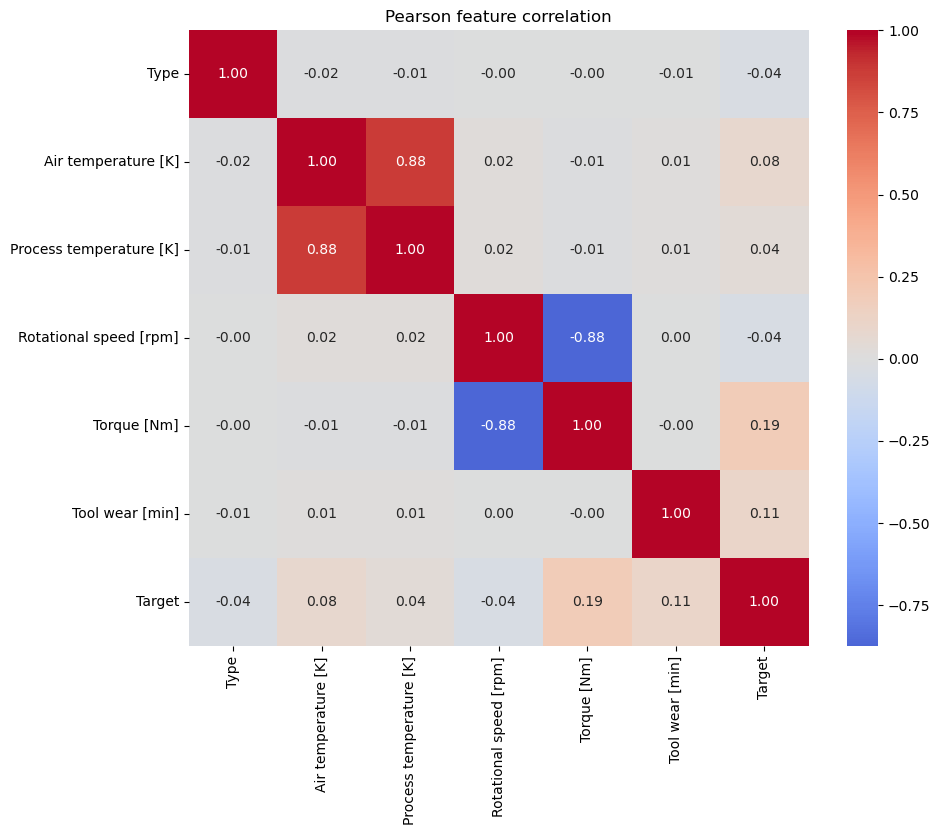

In [120]:
corr_matrix = data_corr.corr(method='pearson')
plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Pearson feature correlation')
plt.show()

The correlation matrix reveals a strong positive relationship between air temperature and process temperature, which is expected because process temperature is influenced by ambient temperature. A strong relationship is also observed between rotational speed and torque, reflecting the physical characteristics of machine operation.

In [121]:
print(corr_matrix['Target'].sort_values(ascending=False))

Target                     1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Type                      -0.036715
Rotational speed [rpm]    -0.044188
Name: Target, dtype: float64


The correlation between individual features and the target variable is generally weak, with torque showing the highest positive correlation (≈0.19). This suggests that machine failure cannot be accurately explained by a single sensor measurement and is likely influenced by the combined interaction of multiple operating conditions.

Since Pearson correlation measures only linear relationships, features with low correlation may still contribute significantly to non-linear machine learning models such as Decision Trees and Random Forests.

### Key Findings from Exploratory Data Analysis

- No missing values or duplicate records were identified.
- Temperature features are approximately normally distributed.
- Rotational speed exhibits positive skewness and several statistical outliers.
- Outliers were retained because the dataset is synthetic and includes Gaussian noise.
- Air temperature and process temperature show strong positive correlation.
- Rotational speed and torque are strongly negative correlated.
- Individual feature correlations with the target are relatively weak, suggesting that machine failure depends on multiple interacting factors rather than a single sensor measurement.

## 5. Data preparing

In [122]:
X = data.drop(['Product ID', 'Target', 'Failure Type'], axis = 1)
y = data.Target

In [123]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [124]:
from sklearn.preprocessing import StandardScaler

#Scaled Values for Logistic Regression and KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [125]:
# Percentage of each category
y.value_counts(normalize=True)

Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

## 6. Train Baseline Models

### Logistic regression

In [126]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

#Confusion matrix
test_conf_matrix = pd.DataFrame(
     confusion_matrix(y_test, y_pred),
     index=['actual no', 'actual yes'],
     columns=['predicted no', 'predicted yes']
 )
print(test_conf_matrix)

            predicted no  predicted yes
actual no           1928              4
actual yes            61              7


In [127]:
#Scores
print("Accuracy score:", accuracy_score(y_test, y_pred))
print("Precision score:", precision_score(y_test, y_pred))
print("Recall score:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))

Accuracy score: 0.9675
Precision score: 0.6363636363636364
Recall score: 0.10294117647058823
F1 score: 0.17721518987341772


### KNN

In [128]:
classifier = KNeighborsClassifier(n_neighbors = 3)
classifier.fit(X_train_scaled, y_train)
y_pred = classifier.predict(X_test_scaled)
#Confusion matrix
test_conf_matrix = pd.DataFrame(
     confusion_matrix(y_test, y_pred),
     index=['actual no', 'actual yes'],
     columns=['predicted no', 'predicted yes']
 )
print(test_conf_matrix)

            predicted no  predicted yes
actual no           1924              8
actual yes            47             21


In [129]:
#Scores
print("Accuracy score:", accuracy_score(y_test, y_pred))
print("Precision score:", precision_score(y_test, y_pred))
print("Recall score:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))

Accuracy score: 0.9725
Precision score: 0.7241379310344828
Recall score: 0.3088235294117647
F1 score: 0.4329896907216495


### Desicion Tree

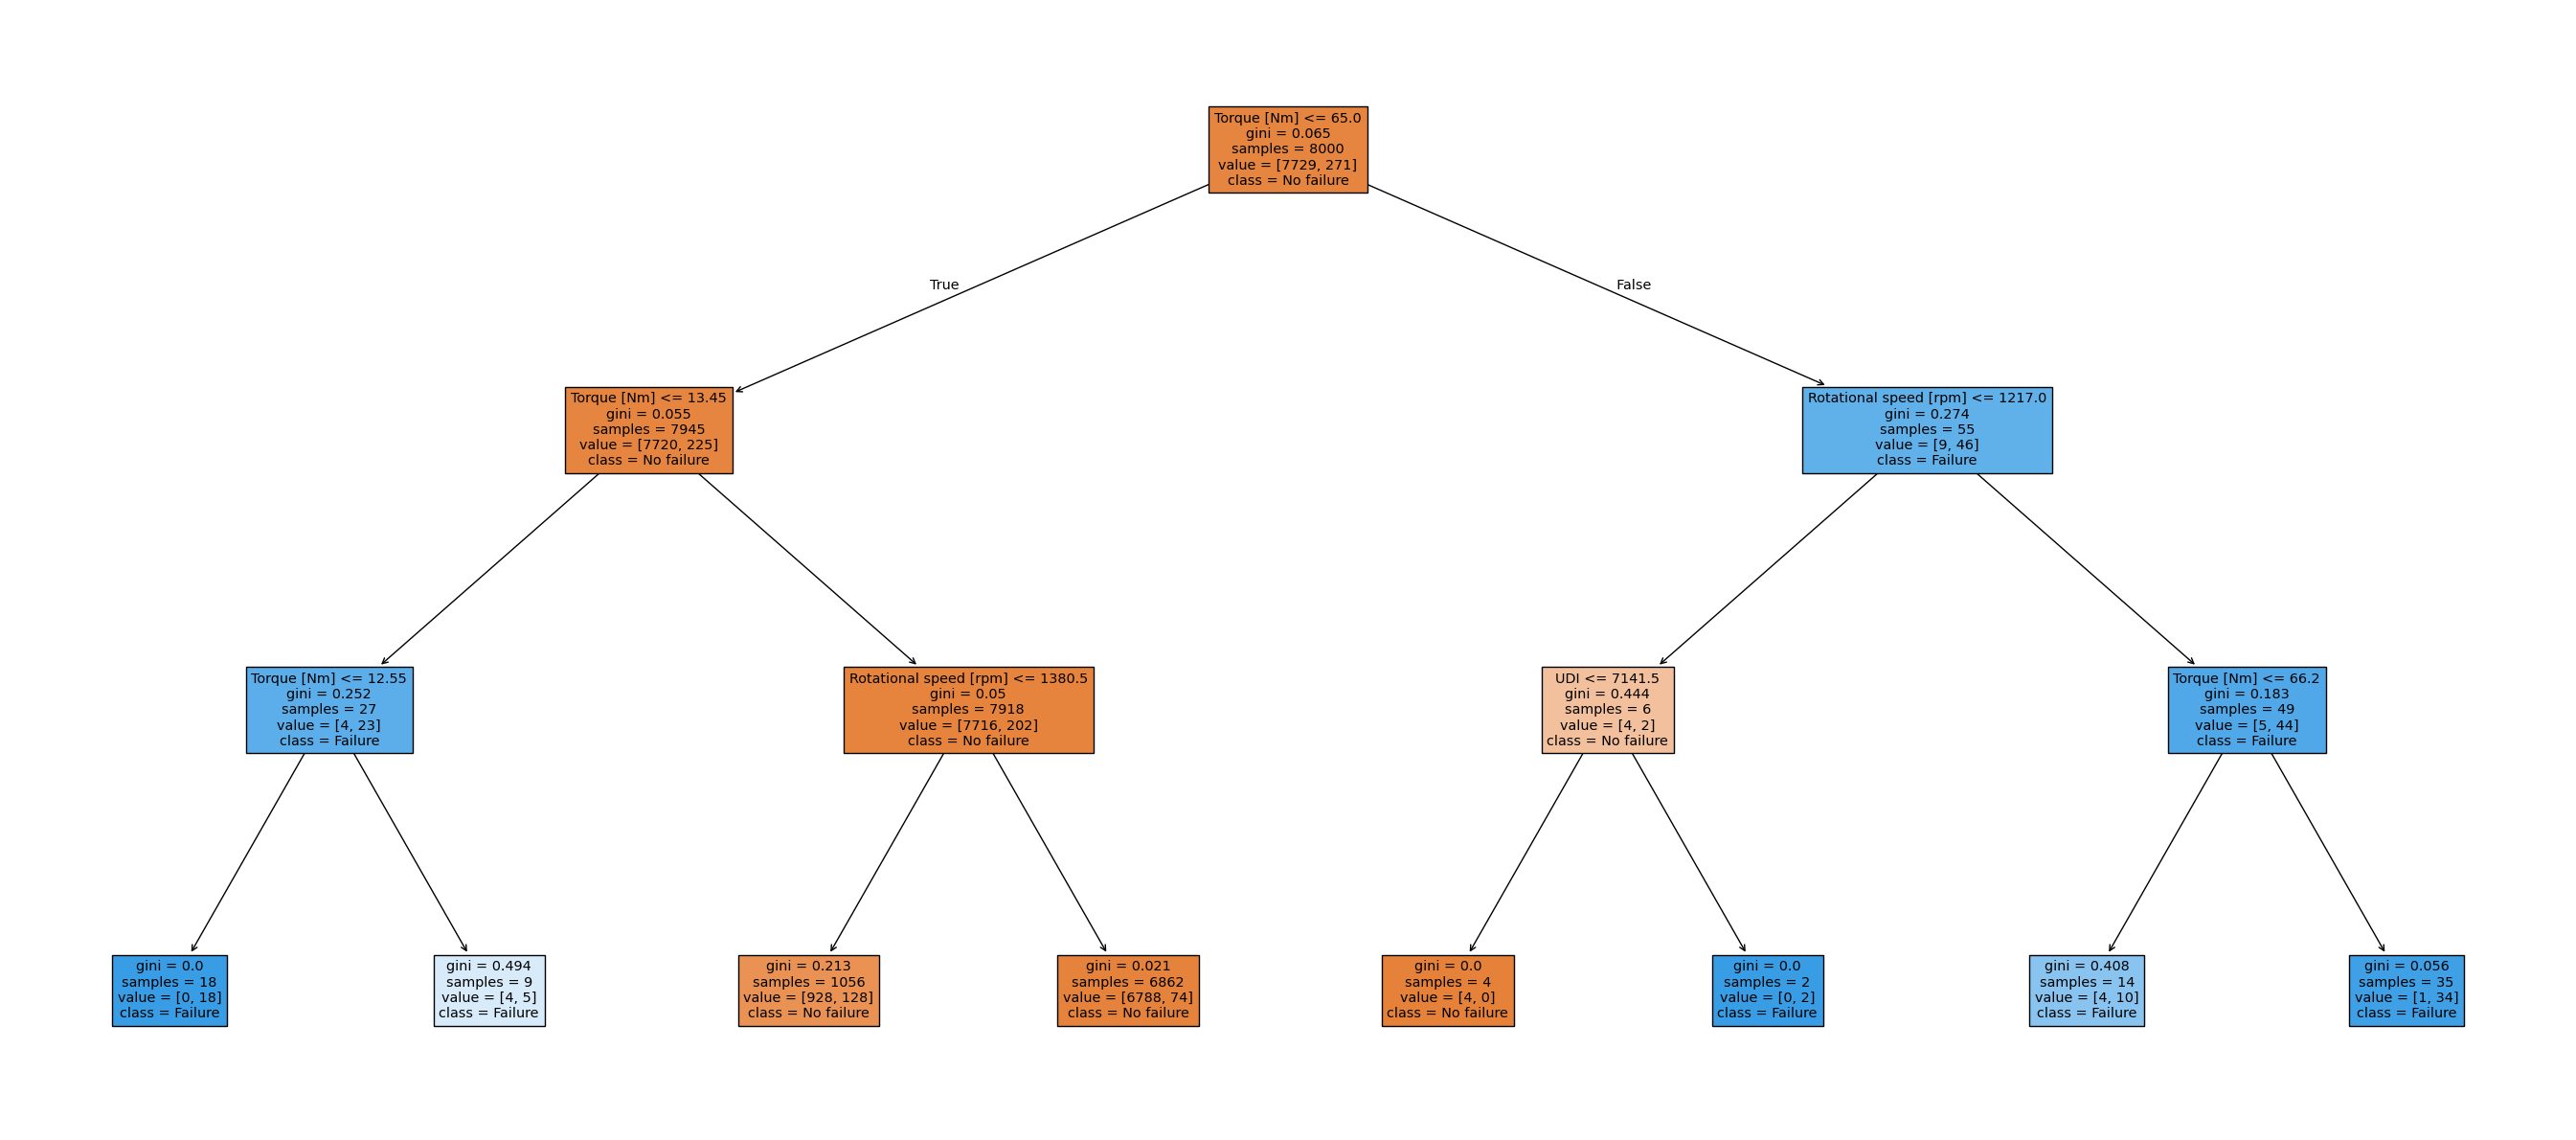

In [130]:
dt = DecisionTreeClassifier(max_depth=3, criterion='gini')
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
from sklearn import tree

plt.figure(figsize=(27,12))
tree.plot_tree(dt, feature_names = X_train.columns, class_names = ['No failure','Failure'], filled=True)
plt.tight_layout()
plt.show()

In [131]:
test_conf_matrix = pd.DataFrame(
     confusion_matrix(y_test, y_pred),
     index=['actual no', 'actual yes'],
     columns=['predicted no', 'predicted yes']
 )
print(test_conf_matrix)

            predicted no  predicted yes
actual no           1929              3
actual yes            55             13


In [132]:
#Scores
print("Accuracy score:", accuracy_score(y_test, y_pred))
print("Precision score:", precision_score(y_test, y_pred))
print("Recall score:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))

Accuracy score: 0.971
Precision score: 0.8125
Recall score: 0.19117647058823528
F1 score: 0.30952380952380953


In [133]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

test_conf_matrix = pd.DataFrame(
     confusion_matrix(y_test, y_pred),
     index=['actual no', 'actual yes'],
     columns=['predicted no', 'predicted yes']
 )
print(test_conf_matrix)

            predicted no  predicted yes
actual no           1711            221
actual yes             5             63


In [134]:
#Scores
print("Accuracy score:", accuracy_score(y_test, y_pred))
print("Precision score:", precision_score(y_test, y_pred))
print("Recall score:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))

Accuracy score: 0.887
Precision score: 0.22183098591549297
Recall score: 0.9264705882352942
F1 score: 0.35795454545454547


- Although all four baseline models achieved good predictive performance, the K-Nearest Neighbors classifier obtained the highest F1-score.
- More importantly, the confusion matrix shows that Random Forest produced the smallest number of false negatives among the evaluated models.
- In predictive maintenance, minimizing false negatives is critical because undetected machine failures may result in unexpected downtime, production interruptions, and increased maintenance costs. Consequently, Random Forest was selected as the strongest baseline model before hyperparameter optimization.

**Since the baseline Random Forest already demonstrates strong Recall performance, hyperparameter tuning may further improve its ability to detect machine failures while maintaining an acceptable Precision.**

In [135]:
# GridSearchCV parameters

n_estimators = [100, 200, 300]
max_depth = [i for i in range(1, 11)]
class_weight = ['balanced', None]

param_grid = {
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'class_weight': class_weight
}

rf = RandomForestClassifier(random_state=42)

In [136]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Five-fold stratified cross-validation will be used during hyperparameter optimization. Stratification preserves the class distribution in each fold, providing a more reliable evaluation for this imbalanced binary classification problem

In [137]:
# GridSearchCV with recall scoring

grid_search_recall = GridSearchCV(estimator = rf, param_grid = param_grid, cv = cv, scoring = 'recall', n_jobs = -1)
grid_search_recall.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced', None], 'max_depth': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [138]:
print(grid_search_recall.best_params_)
print(grid_search_recall.best_score_)

best_recall_model = grid_search_recall.best_estimator_  

{'class_weight': 'balanced', 'max_depth': 4, 'n_estimators': 100}
0.8673400673400673


In [139]:
y_pred = best_recall_model.predict(X_test)
test_conf_matrix = pd.DataFrame(
     confusion_matrix(y_test, y_pred),
     index=['actual no', 'actual yes'],
     columns=['predicted no', 'predicted yes']
 )
print(test_conf_matrix)

            predicted no  predicted yes
actual no           1744            188
actual yes             6             62


In [140]:
#Scores
print("Accuracy score:", accuracy_score(y_test, y_pred))
print("Precision score:", precision_score(y_test, y_pred))
print("Recall score:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))

Accuracy score: 0.903
Precision score: 0.248
Recall score: 0.9117647058823529
F1 score: 0.389937106918239


In [39]:
# GridSearchCV with f1 scoring

grid_search_f1 = GridSearchCV(estimator = rf, param_grid = param_grid, cv = cv, scoring = 'f1', n_jobs = -1)
grid_search_f1.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced', None], 'max_depth': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [40]:
print(grid_search_f1.best_params_)
print(grid_search_f1.best_score_)

best_f1_model = grid_search_f1.best_estimator_ 

{'class_weight': None, 'max_depth': 10, 'n_estimators': 300}
0.7065125887790983


In [41]:
y_pred = best_f1_model.predict(X_test)

test_conf_matrix = pd.DataFrame(
     confusion_matrix(y_test, y_pred),
     index=['actual no', 'actual yes'],
     columns=['predicted no', 'predicted yes']
 )
print(test_conf_matrix)

            predicted no  predicted yes
actual no           1929              3
actual yes            25             43


In [42]:
#Scores
print("Accuracy score:", accuracy_score(y_test, y_pred))
print("Precision score:", precision_score(y_test, y_pred))
print("Recall score:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))

0.986
0.9347826086956522
0.6323529411764706
0.7543859649122807


**Although optimizing for F1-score produced a more balanced classifier, the model optimized for Recall was selected because reducing false negatives is more critical in predictive maintenance than maximizing overall classification balance**

## 7. Feature Importance

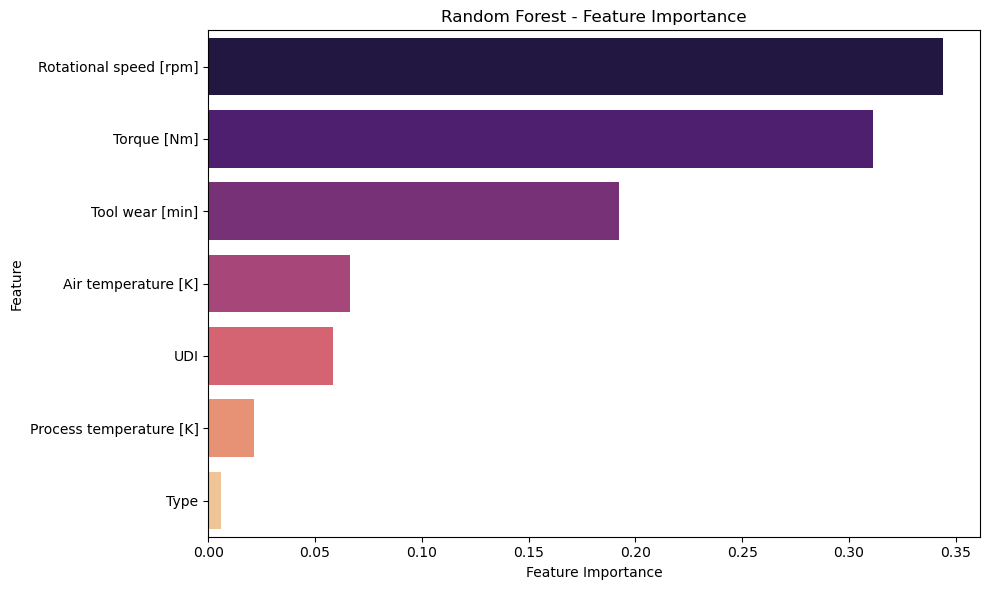

In [56]:
feature_importance = pd.Series(
    best_recall_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sb.barplot(x=feature_importance.values, y=feature_importance.index, hue = feature_importance.index, palette='magma', legend = False)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

**The model identified Rotational Speed, Torque and Tool Wear as the most influential predictors of machine failure.**

## 8. ROC Curve, Precision-Recall Curve, Finding optimal probability threshold

In [ ]:
# Finding probabilities of positive class (Failure) from the best model
y_proba = best_recall_model.predict_proba(X_test)[:, 1]

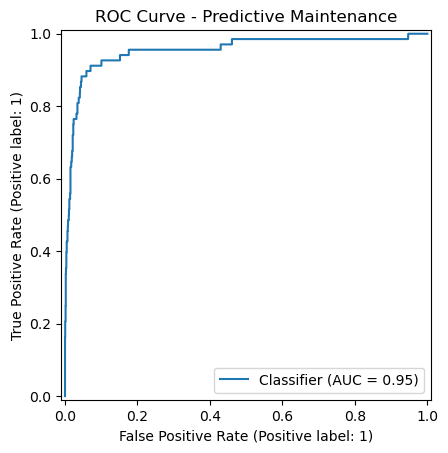

In [78]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve - Predictive Maintenance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [77]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

j_scores = tpr - fpr
best_idx_roc = j_scores.argmax()
best_threshold_roc = thresholds_roc[best_idx_roc]

print(f'ROC AUC: {auc_score:.3f}')
print(f'Optimal threshold (ROC/Youden J): {best_threshold_roc:.3f}')
print(f'TPR on this treshold: {tpr[best_idx_roc]:.3f}')
print(f'FPR on this treshold: {fpr[best_idx_roc]:.3f}')

ROC AUC: 0.954
Optimal threshold (ROC/Youden J): 0.549
TPR on this treshold: 0.912
FPR on this treshold: 0.070


In [65]:
y_pred_custom = (y_proba >= best_threshold_roc).astype(int)

test_conf_matrix = pd.DataFrame(
     confusion_matrix(y_test, y_pred_custom),
     index=['actual no', 'actual yes'],
     columns=['predicted no', 'predicted yes']
 )
print(test_conf_matrix)

#Scores
print(accuracy_score(y_test, y_pred_custom))
print(precision_score(y_test, y_pred_custom))
print(recall_score(y_test, y_pred_custom))
print(f1_score(y_test, y_pred_custom))

            predicted no  predicted yes
actual no           1796            136
actual yes             6             62
0.929
0.31313131313131315
0.9117647058823529
0.46616541353383456


## Precision-Recall Curve 

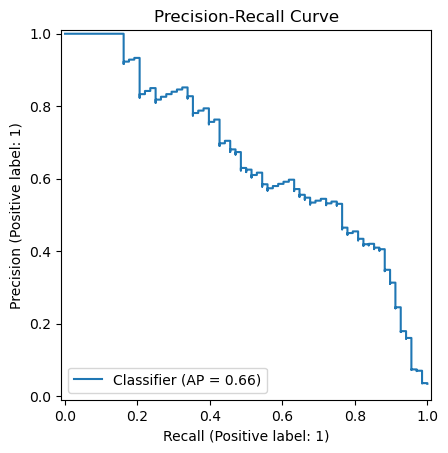

In [59]:
## Precision-Recall  
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

In [80]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

best_idx_f1 = f1_scores.argmax()
best_threshold_f1 = thresholds_pr[best_idx_f1]

print(f'Optimal threshold (F1): {best_threshold_f1:.3f}')

Optimal threshold (PR/F1): 0.648
Precision on this treshold: 0.531
Recall on this treshold: 0.765
F1 on this treshold: 0.627


In [84]:
target_recall = 0.95
idx = np.where(recall[:-1] >= target_recall)[0]
best_idx = idx[-1]
best_threshold_recall = thresholds_pr[best_idx]
print(f'Optimal threshold (recall): {best_threshold_recall:.3f}')

Optimal threshold (recall): 0.330
Precision on this treshold: 0.160
Recall on this treshold: 0.956
F1 on this treshold: 0.275


In [81]:
y_pred_custom = (y_proba >= best_threshold_f1).astype(int)

test_conf_matrix = pd.DataFrame(
     confusion_matrix(y_test, y_pred_custom),
     index=['actual no', 'actual yes'],
     columns=['predicted no', 'predicted yes']
 )
print(test_conf_matrix)

#Scores
print(accuracy_score(y_test, y_pred_custom))
print(precision_score(y_test, y_pred_custom))
print(recall_score(y_test, y_pred_custom))
print(f1_score(y_test, y_pred_custom))

            predicted no  predicted yes
actual no           1886             46
actual yes            16             52
0.969
0.5306122448979592
0.7647058823529411
0.6265060240963856


In [83]:
y_pred_custom = (y_proba >= best_threshold_recall).astype(int)

test_conf_matrix = pd.DataFrame(
     confusion_matrix(y_test, y_pred_custom),
     index=['actual no', 'actual yes'],
     columns=['predicted no', 'predicted yes']
 )
print(test_conf_matrix)

#Scores
print(accuracy_score(y_test, y_pred_custom))
print(precision_score(y_test, y_pred_custom))
print(recall_score(y_test, y_pred_custom))
print(f1_score(y_test, y_pred_custom))

            predicted no  predicted yes
actual no           1592            340
actual yes             3             65
0.8285
0.16049382716049382
0.9558823529411765
0.2748414376321353


**Although the ROC-based threshold achieved a better balance between sensitivity and specificity, the threshold selected from the Precision–Recall analysis detected a higher proportion of machine failures. Since avoiding missed failures is the primary business objective, the Precision–Recall threshold on recall is more suitable for deployment in this predictive maintenance scenario.**